Colab is making it easier than ever to integrate powerful Generative AI capabilities into your projects. We are launching public preview for a simple and intuitive Python library (google.colab.ai) to access state-of-the-art language models directly within Colab environments. All users have free access to most popular LLMs, while paid users have access to a wider selection of models. This means users can spend less time on configuration and set up and more time bringing their ideas to life. With just a few lines of code, you can now perform a variety of tasks:
- Generate text
- Translate languages
- Write creative content
- Categorize text

Happy Coding!


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb)

In [ ]:
# @title List available models
from google.colab import ai

ai.list_models()

['google/gemini-2.0-flash',
 'google/gemini-2.0-flash-lite',
 'google/gemini-2.5-flash',
 'google/gemini-2.5-flash-lite',
 'google/gemini-2.5-pro',
 'google/gemma-3-12b',
 'google/gemma-3-1b',
 'google/gemma-3-27b',
 'google/gemma-3-4b']

Choosing a Model
The model names give you a hint about their capabilities and intended use:

Pro: These are the most capable models, ideal for complex reasoning, creative tasks, and detailed analysis.

Flash: These models are optimized for high speed and efficiency, making them great for summarization, chat applications, and tasks requiring rapid responses.

Gemma: These are lightweight, open-weight models suitable for a variety of text generation tasks and are great for experimentation.

In [ ]:
# @title Simple batch generation example
# Only text-to-text input/output is supported
from google.colab import ai

response = ai.generate_text("What is the capital of France?")
print(response)

The capital of France is **Paris**.



In [ ]:
# @title Choose a different model
from google.colab import ai

response = ai.generate_text("What is the capital of England", model_name='google/gemini-2.0-flash-lite')
print(response)

The capital of England is **London**.



For longer text generations, you can stream the response. This displays the output token by token as it's generated, rather than waiting for the entire response to complete. This provides a more interactive and responsive experience. To enable this, simply set stream=True.

In [ ]:
# @title Simple streaming example
from google.colab import ai

stream = ai.generate_text("Tell me a short story.", stream=True)
for text in stream:
  print(text, end='')

The lighthouse keeper, Silas, was a man of routine. Every night, for fifty years, he'd lit the lamp, a beacon against the treacherous rocks that gnawed at the coastline. The sea was his companion, his enemy, and his only confidante. He knew its moods better than his own.

One stormy night, the wind howled like a banshee. The waves crashed against the tower, shaking it to its core. Silas, clinging to the railing, felt a fear he hadn't experienced in decades. This wasn't just a storm; this was a monster.

Suddenly, a small, wooden boat, tossed about like a toy, appeared in the raging sea. He squinted, his heart leaping into his throat. A child. Alone.

Ignoring the raging tempest, Silas raced down the winding stairs, his old bones protesting with every step. He launched his small rescue boat, a fragile craft against the fury of the storm.

Fighting the waves, he reached the child. A girl, no older than seven, clung to the wreckage, her face white with terror. With a strength born of desp

In [ ]:
#@title Text formatting setup
#code is not necessary for colab.ai, but is useful in fomatting text chunks
import sys

class LineWrapper:
    def __init__(self, max_length=80):
        self.max_length = max_length
        self.current_line_length = 0

    def print(self, text_chunk):
        i = 0
        n = len(text_chunk)
        while i < n:
            start_index = i
            while i < n and text_chunk[i] not in ' \n': # Find end of word
                i += 1
            current_word = text_chunk[start_index:i]

            delimiter = ""
            if i < n: # If not end of chunk, we found a delimiter
                delimiter = text_chunk[i]
                i += 1 # Consume delimiter

            if current_word:
                needs_leading_space = (self.current_line_length > 0)

                # Case 1: Word itself is too long for a line (must be broken)
                if len(current_word) > self.max_length:
                    if needs_leading_space: # Newline if current line has content
                        sys.stdout.write('\n')
                        self.current_line_length = 0
                    for char_val in current_word: # Break the long word
                        if self.current_line_length >= self.max_length:
                            sys.stdout.write('\n')
                            self.current_line_length = 0
                        sys.stdout.write(char_val)
                        self.current_line_length += 1
                # Case 2: Word doesn't fit on current line (print on new line)
                elif self.current_line_length + (1 if needs_leading_space else 0) + len(current_word) > self.max_length:
                    sys.stdout.write('\n')
                    sys.stdout.write(current_word)
                    self.current_line_length = len(current_word)
                # Case 3: Word fits on current line
                else:
                    if needs_leading_space:
                        # Define punctuation that should not have a leading space
                        # when they form an entire "word" (token) following another word.
                        no_leading_space_punctuation = {
                            ",", ".", ";", ":", "!", "?",        # Standard sentence punctuation
                            ")", "]", "}",                     # Closing brackets
                            "'s", "'S", "'re", "'RE", "'ve", "'VE", # Common contractions
                            "'m", "'M", "'ll", "'LL", "'d", "'D",
                            "n't", "N'T",
                            "...", "…"                          # Ellipses
                        }
                        if current_word not in no_leading_space_punctuation:
                            sys.stdout.write(' ')
                            self.current_line_length += 1
                    sys.stdout.write(current_word)
                    self.current_line_length += len(current_word)

            if delimiter == '\n':
                sys.stdout.write('\n')
                self.current_line_length = 0
            elif delimiter == ' ':
                # If line is full and a space delimiter arrives, it implies a wrap.
                if self.current_line_length >= self.max_length:
                    sys.stdout.write('\n')
                    self.current_line_length = 0

        sys.stdout.flush()


In [ ]:
# @title Formatted streaming example
from google.colab import ai

wrapper = LineWrapper()
for chunk in ai.generate_text('Give me a long winded description about the evolution of the Roman Empire.', model_name='google/gemini-2.0-flash', stream=True):
  wrapper.print(chunk)

Alright, settle in, because the Roman Empire’s evolution wasn't a tidy, linear
process. It was a centuries-long, tumultuous transformation, marked by
breathtaking innovation, brutal power struggles, and a slow, creeping societal
decay. We're talking about a journey from a humble city-state in the Italian
peninsula to a sprawling, multifaceted empire that left an indelible mark on
law, language, architecture, governance, and even our very understanding of the
world.

It all began, as legend would have it, with Romulus and Remus, twin brothers
raised by a she-wolf, who founded the city of Rome in 753 BCE. Now, that’s just
a legend, but it serves to highlight the foundational spirit of Rome: ambition,
strength, and a certain ruthlessness. Initially, Rome was ruled by a monarchy, a
system eventually deemed unsatisfactory by the powerful patrician class. This
led to the **Roman Republic**, established around 509 BCE, a watershed moment
that would define the early character of Rome.

The Rep

## Data Loading and Initial Inspection

First, I will load the provided Excel file into a pandas DataFrame and display its basic information to understand the data structure and types.

In [1]:
import pandas as pd

# Load the Excel file into a pandas DataFrame
file_path = '/content/ecommerce_powerbi_ready.xlsx'
df = pd.read_excel(file_path)

# Display the first 5 rows of the DataFrame
print("First 5 rows of the DataFrame:")
display(df.head())

# Display general information about the DataFrame
print("\nGeneral information about the DataFrame:")
df.info()

First 5 rows of the DataFrame:


,Order ID,Date,Customer Name,Email,Country,Category,Product,Quantity,Price,Total Amount,Payment Method,Status,Unnamed: 12,Unnamed: 13
0,ORD-00001,2024-07-22,Customer 1,customer1@email.com,Germany,Food,Organic Honey,10,196.31,1963.10,Cash on Delivery,Pending,NaN,NaN
1,ORD-00002,2023-12-16,Customer 2,customer2@email.com,USA,Clothing,Dress,10,187.32,1873.20,Cash on Delivery,Shipped,NaN,NaN
2,ORD-00003,2024-03-15,Customer 3,customer3@email.com,Australia,Beauty,Nail Polish,1,110.32,110.32,Credit Card,Shipped,NaN,NaN
3,ORD-00004,2024-02-22,Customer 4,customer4@email.com,Germany,Books,Fiction Novel,6,154.57,927.42,Debit Card,Cancelled,NaN,NaN
4,ORD-00005,2024-01-01,Customer 5,customer5@email.com,India,Clothing,Dress,9,277.16,2494.44,Debit Card,Shipped,NaN,NaN



General information about the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1000 non-null   object 
 1   Date            1000 non-null   object 
 2   Customer Name   1000 non-null   object 
 3   Email           1000 non-null   object 
 4   Country         1000 non-null   object 
 5   Category        1000 non-null   object 
 6   Product         1000 non-null   object 
 7   Quantity        1000 non-null   int64  
 8   Price           1000 non-null   float64
 9   Total Amount    1000 non-null   float64
 10  Payment Method  1000 non-null   object 
 11  Status          1000 non-null   object 
 12  Unnamed: 12     0 non-null      float64
 13  Unnamed: 13     6 non-null      object 
dtypes: float64(3), int64(1), object(10)
memory usage: 109.5+ KB


## Data Cleaning and Preprocessing

Based on the `df.info()` output, columns 'Unnamed: 12' and 'Unnamed: 13' contain a high number of null values. These columns appear to be empty and do not provide meaningful information, so I will drop them. Additionally, I will convert the 'Date' column to a datetime object to enable time-based analysis.

In [2]:
# Drop the 'Unnamed: 12' and 'Unnamed: 13' columns
df_cleaned = df.drop(columns=['Unnamed: 12', 'Unnamed: 13'])

# Convert 'Date' column to datetime objects
df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'])

print("DataFrame after dropping 'Unnamed' columns and converting 'Date' to datetime:")
display(df_cleaned.head())
print("\nUpdated general information of the DataFrame:")
df_cleaned.info()

DataFrame after dropping 'Unnamed' columns and converting 'Date' to datetime:


,Order ID,Date,Customer Name,Email,Country,Category,Product,Quantity,Price,Total Amount,Payment Method,Status
0,ORD-00001,2024-07-22,Customer 1,customer1@email.com,Germany,Food,Organic Honey,10,196.31,1963.10,Cash on Delivery,Pending
1,ORD-00002,2023-12-16,Customer 2,customer2@email.com,USA,Clothing,Dress,10,187.32,1873.20,Cash on Delivery,Shipped
2,ORD-00003,2024-03-15,Customer 3,customer3@email.com,Australia,Beauty,Nail Polish,1,110.32,110.32,Credit Card,Shipped
3,ORD-00004,2024-02-22,Customer 4,customer4@email.com,Germany,Books,Fiction Novel,6,154.57,927.42,Debit Card,Cancelled
4,ORD-00005,2024-01-01,Customer 5,customer5@email.com,India,Clothing,Dress,9,277.16,2494.44,Debit Card,Shipped



Updated general information of the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1000 non-null   object        
 1   Date            1000 non-null   datetime64[ns]
 2   Customer Name   1000 non-null   object        
 3   Email           1000 non-null   object        
 4   Country         1000 non-null   object        
 5   Category        1000 non-null   object        
 6   Product         1000 non-null   object        
 7   Quantity        1000 non-null   int64         
 8   Price           1000 non-null   float64       
 9   Total Amount    1000 non-null   float64       
 10  Payment Method  1000 non-null   object        
 11  Status          1000 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(8)
memory usage: 93.9+ KB


## Univariable Analysis

### Numerical Variables

I will analyze the numerical columns (`Quantity`, `Price`, `Total Amount`) by computing their descriptive statistics and visualizing their distributions using histograms. This will help us understand their central tendency, spread, and shape.

Descriptive Statistics for Numerical Columns:



,Quantity,Price,Total Amount
count,1000.000000,1000.000000,1000.000000
mean,5.414000,268.382520,1450.872570
std,2.995927,145.405169,1203.350515
min,1.000000,10.410000,20.410000
25%,3.000000,140.360000,444.062500
50%,5.000000,270.825000,1113.720000
75%,8.000000,392.660000,2169.390000
max,10.000000,509.990000,5071.200000


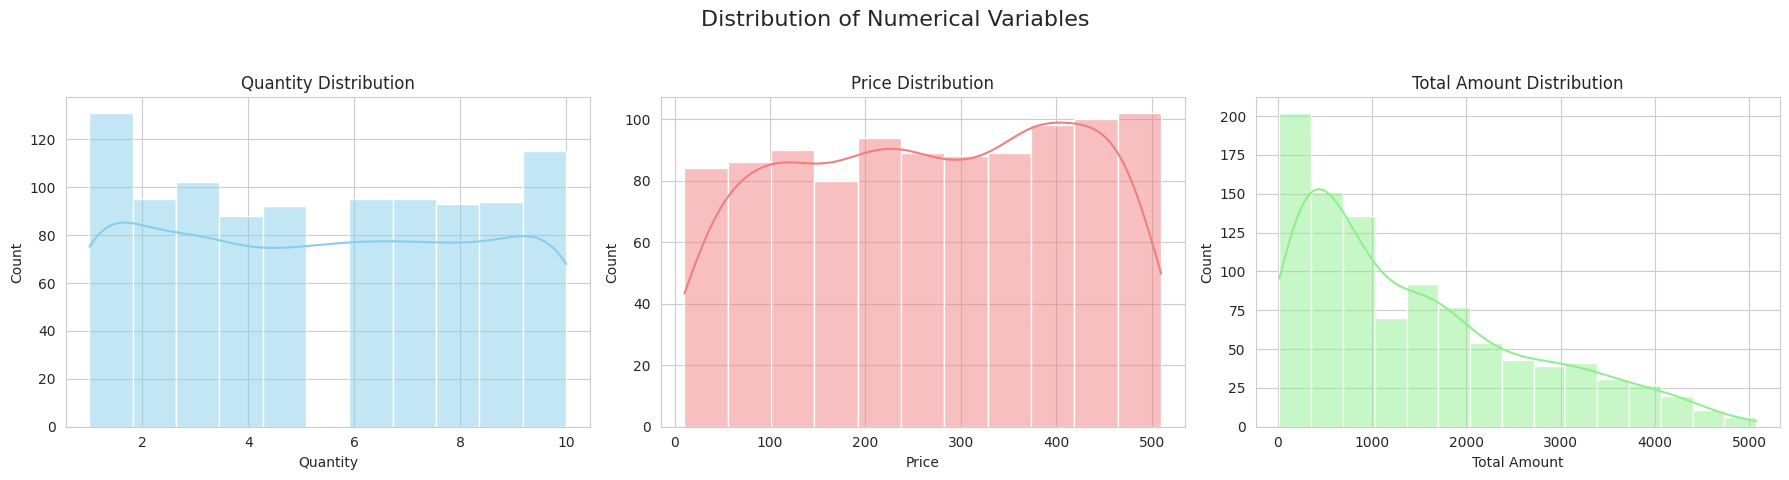

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Descriptive statistics for numerical columns
print("Descriptive Statistics for Numerical Columns:\n")
display(df_cleaned[['Quantity', 'Price', 'Total Amount']].describe())

# Plotting histograms for numerical columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution of Numerical Variables', fontsize=16)

sns.histplot(df_cleaned['Quantity'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Quantity Distribution')

sns.histplot(df_cleaned['Price'], kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Price Distribution')

sns.histplot(df_cleaned['Total Amount'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Total Amount Distribution')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Categorical Variables

I will analyze the categorical columns (`Country`, `Category`, `Payment Method`, `Status`) by showing their value counts and visualizing their distributions using count plots. This will help us understand the frequency of each category.

/tmp/ipykernel_16098/2484292062.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_cleaned[col], order=df_cleaned[col].value_counts().index, palette='viridis')
/tmp/ipykernel_16098/2484292062.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_cleaned[col], order=df_cleaned[col].value_counts().index, palette='viridis')
/tmp/ipykernel_16098/2484292062.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_cleaned[col], order=df_cleaned[col].value_counts().index, palette='viridis')



Value Counts for Country:

Country
USA          137
Germany      134
Japan        132
India        131
Australia    120
UK           117
Canada       115
France       114
Name: count, dtype: int64

Value Counts for Category:

Category
Clothing         139
Toys             135
Home & Garden    134
Beauty           129
Electronics      124
Sports           124
Books            108
Food             107
Name: count, dtype: int64

Value Counts for Payment Method:

Payment Method
Debit Card          215
PayPal              205
Cash on Delivery    197
Credit Card         196
Bank Transfer       187
Name: count, dtype: int64

Value Counts for Status:

Status
Processing    226
Shipped       211
Pending       191
Completed     190
Cancelled     182
Name: count, dtype: int64


/tmp/ipykernel_16098/2484292062.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_cleaned[col], order=df_cleaned[col].value_counts().index, palette='viridis')


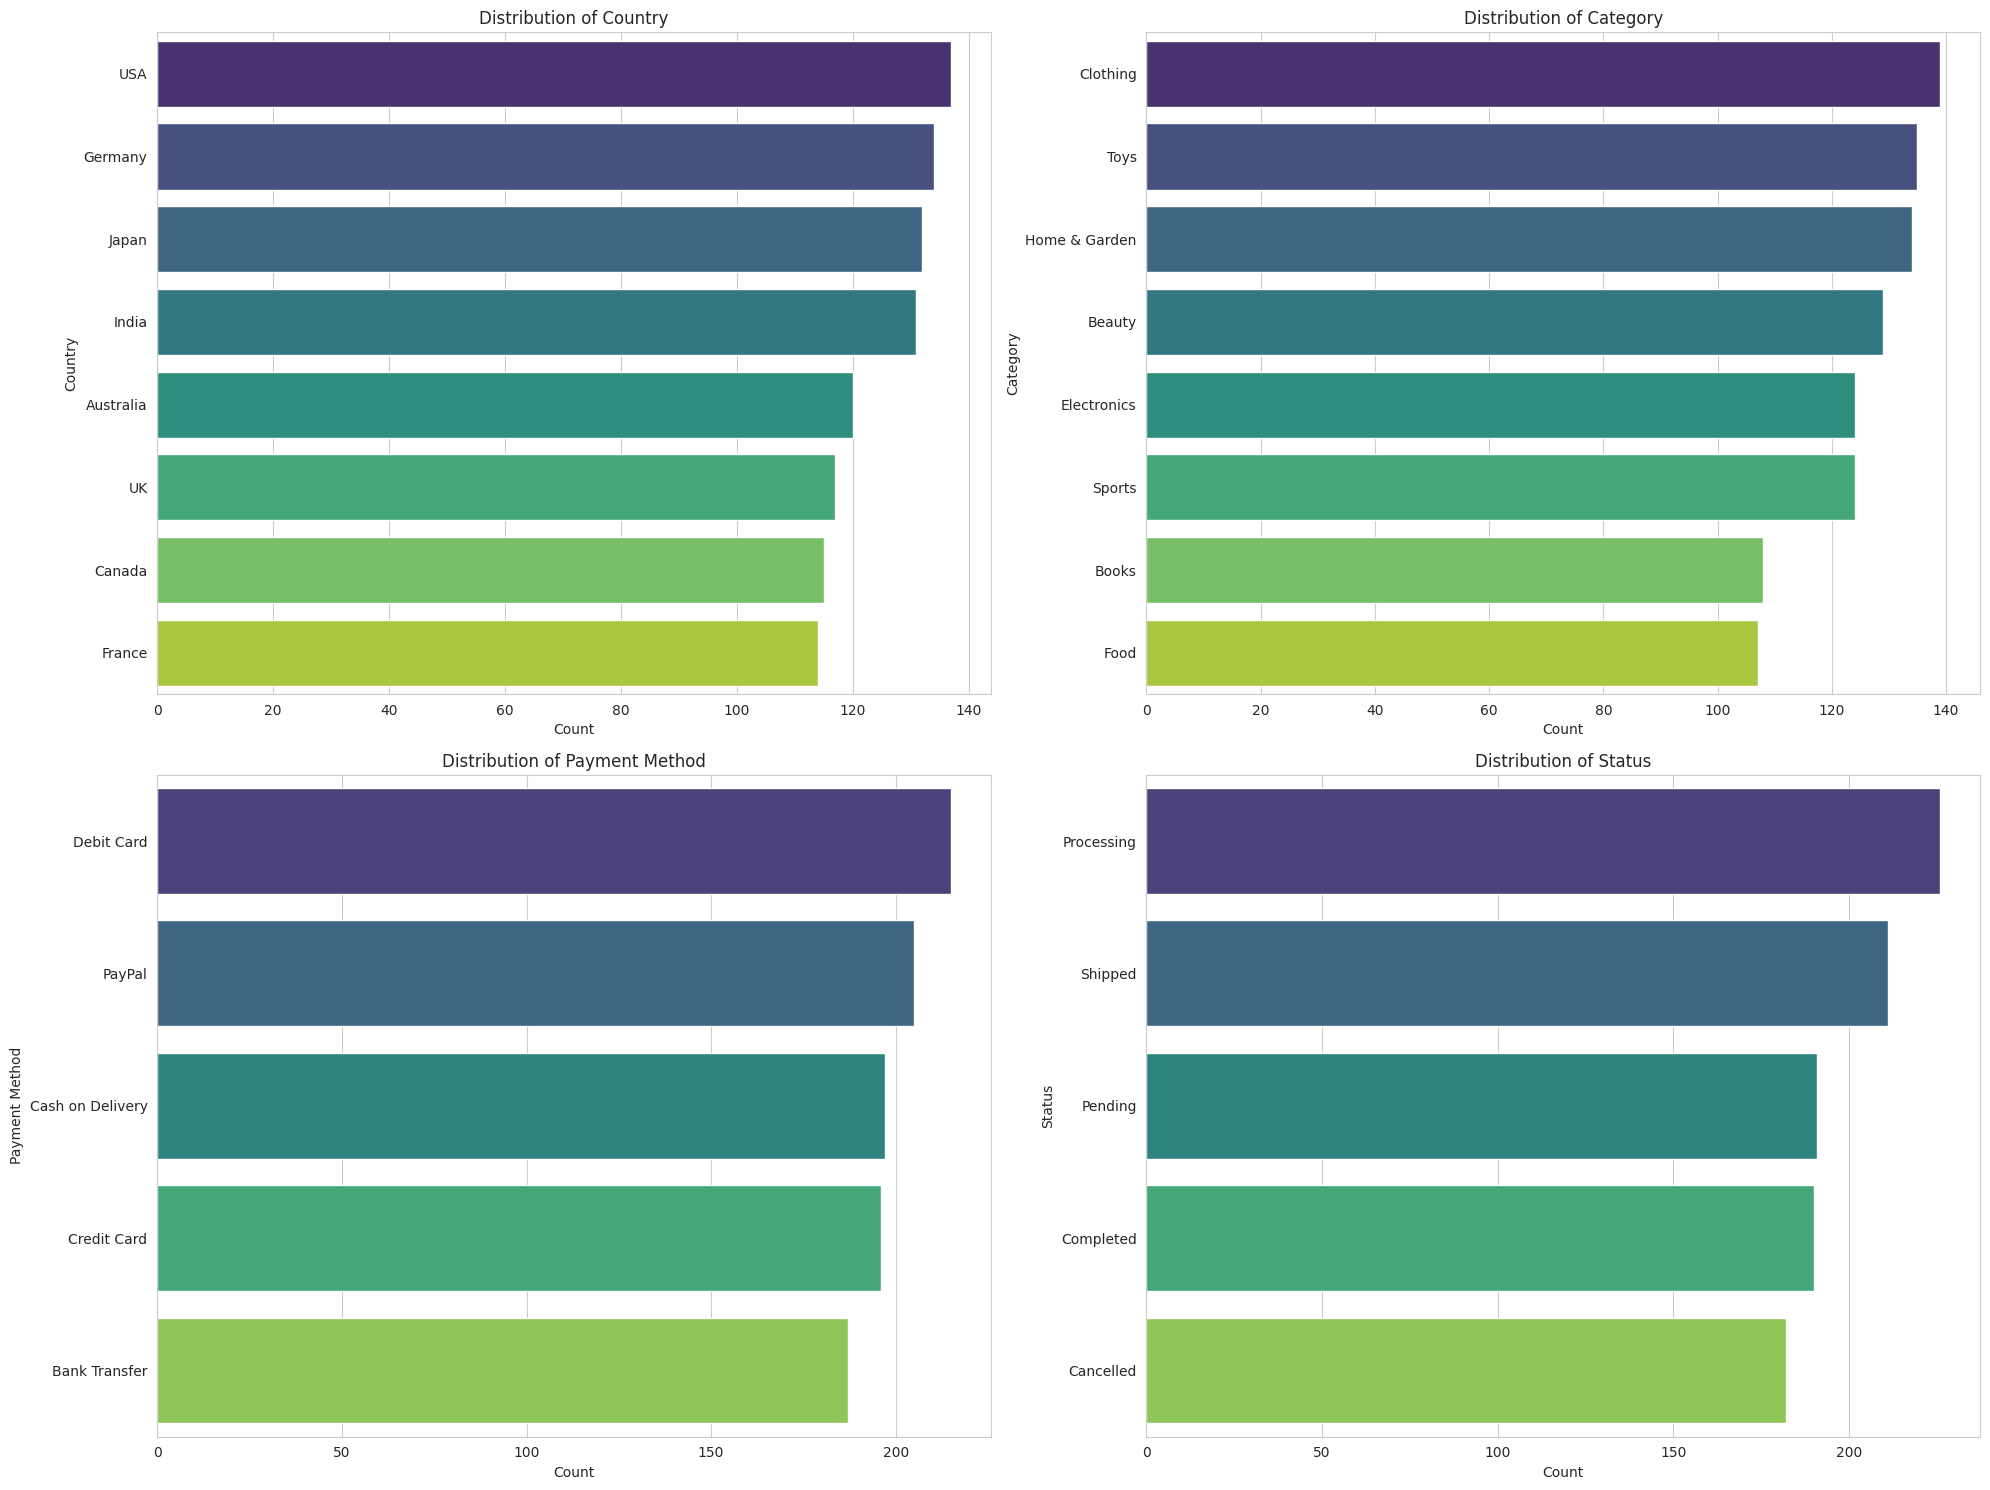

In [4]:
# Univariate analysis for categorical columns
categorical_cols = ['Country', 'Category', 'Payment Method', 'Status']

plt.figure(figsize=(20, 15))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 2, i) # Arrange plots in a 2x2 grid
    sns.countplot(y=df_cleaned[col], order=df_cleaned[col].value_counts().index, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    print(f"\nValue Counts for {col}:\n")
    print(df_cleaned[col].value_counts())
plt.tight_layout()
plt.show()

## Bi-variable Analysis

### Numerical vs. Categorical Variables

I will use box plots to visualize the relationship between 'Total Amount' and key categorical variables such as `Country`, `Category`, `Payment Method`, and `Status`. This will help us identify how sales performance varies across different segments.

/tmp/ipykernel_16098/776738986.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Total Amount', y=col, data=df_cleaned, palette='viridis')
/tmp/ipykernel_16098/776738986.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Total Amount', y=col, data=df_cleaned, palette='viridis')
/tmp/ipykernel_16098/776738986.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Total Amount', y=col, data=df_cleaned, palette='viridis')
/tmp/ipykernel_16098/776738986.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

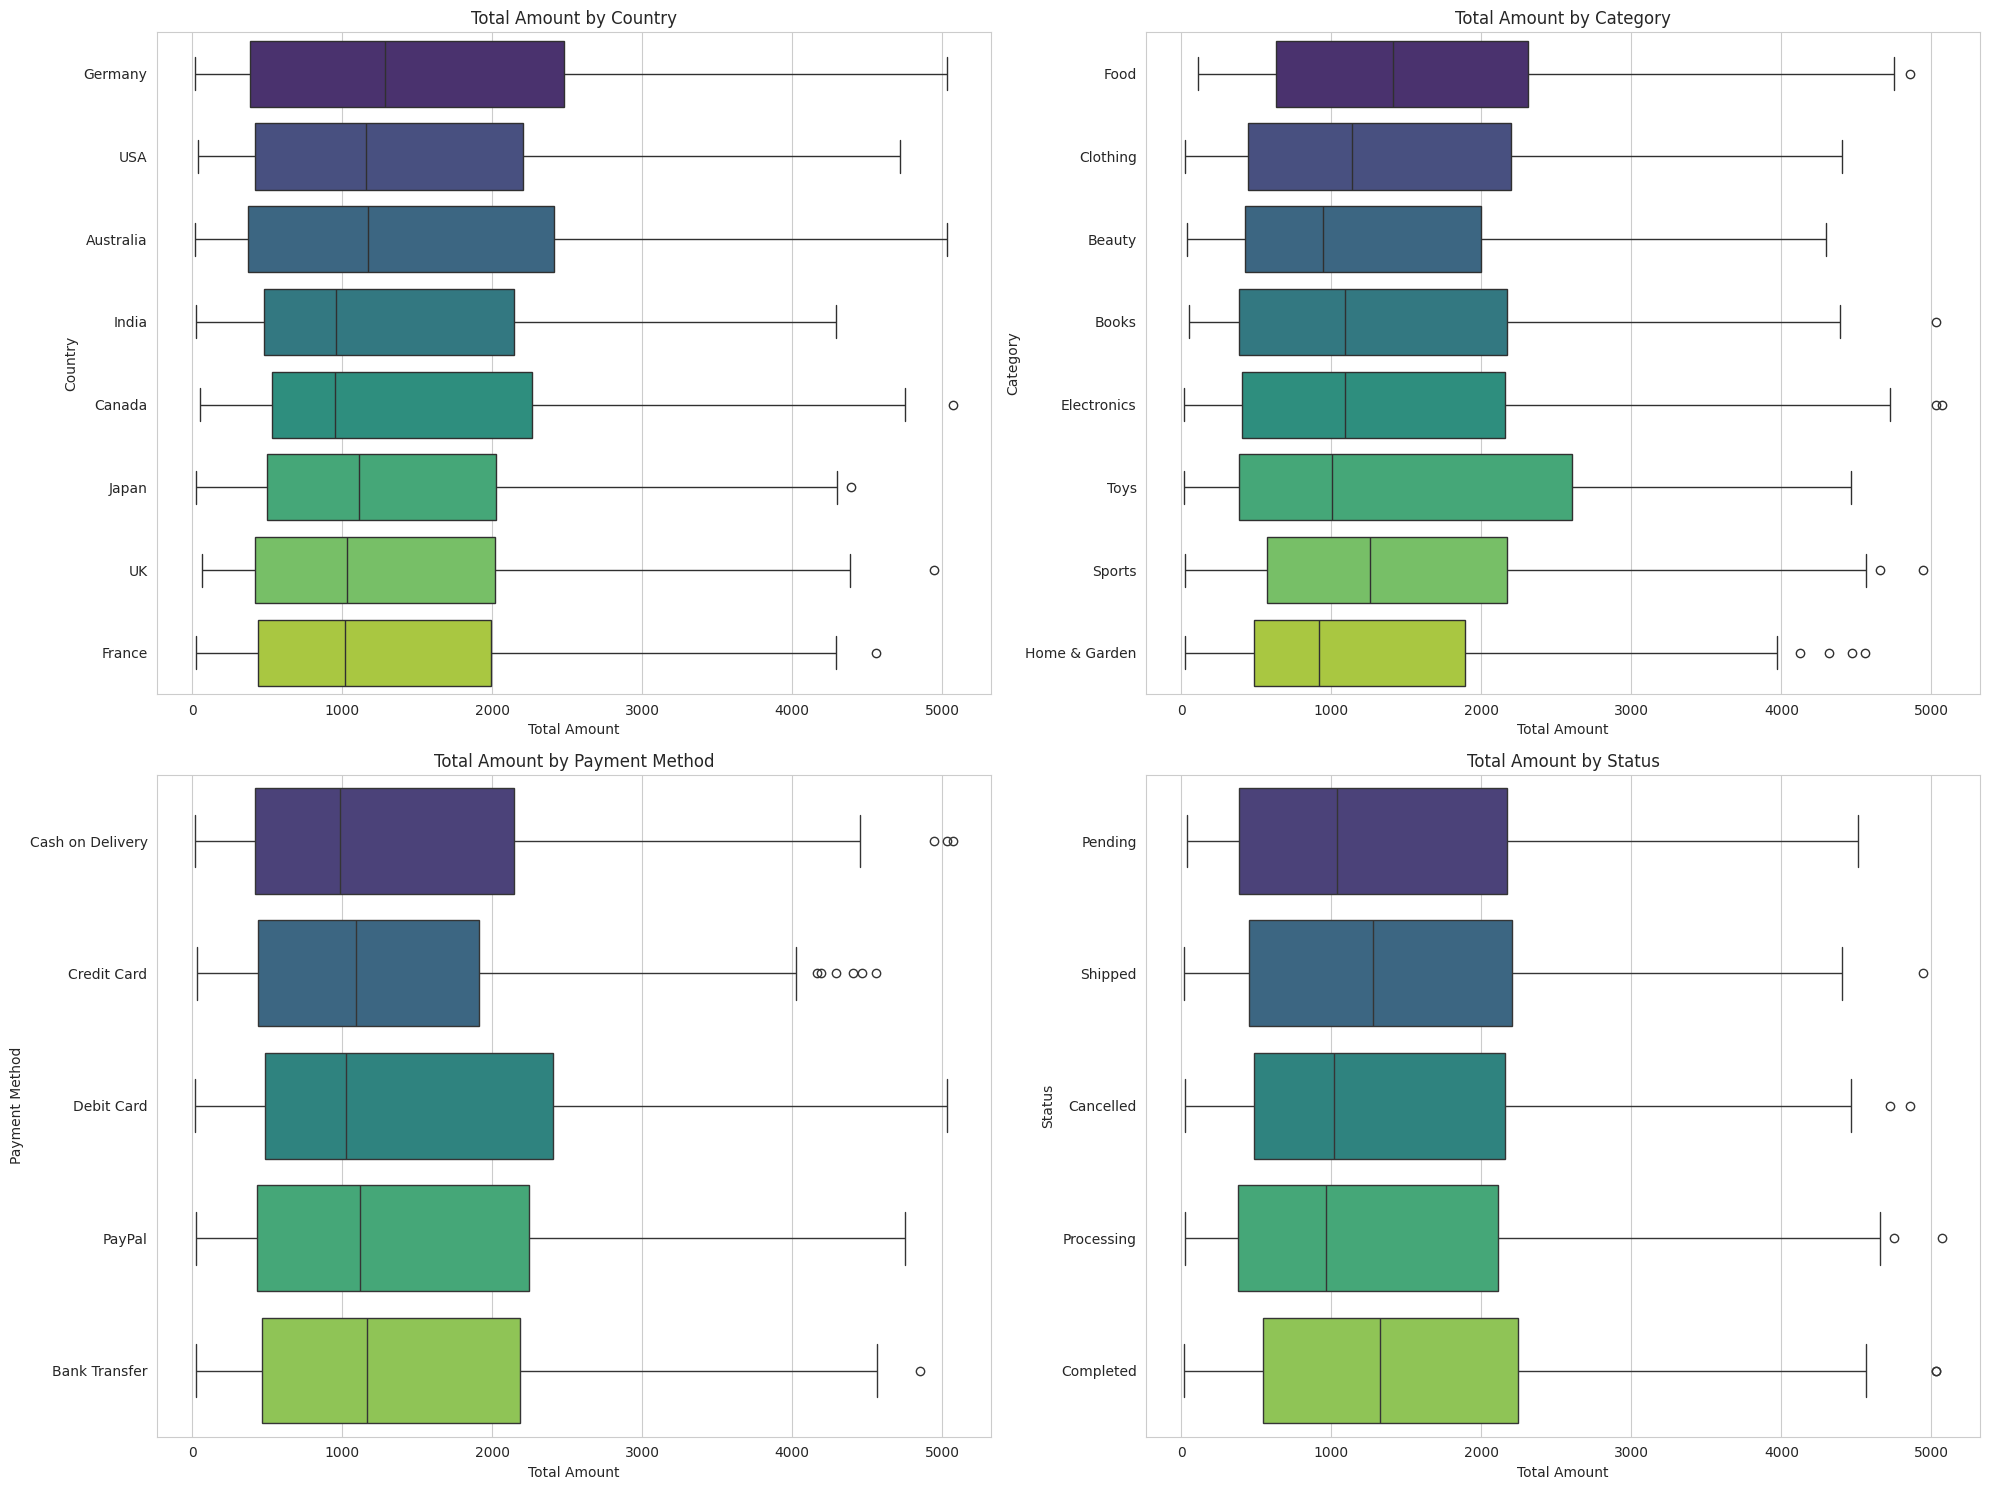

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Bi-variable analysis: Total Amount vs. Categorical variables (Box plots)
categorical_cols_for_bivar = ['Country', 'Category', 'Payment Method', 'Status']

plt.figure(figsize=(20, 15))
for i, col in enumerate(categorical_cols_for_bivar, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='Total Amount', y=col, data=df_cleaned, palette='viridis')
    plt.title(f'Total Amount by {col}')
    plt.xlabel('Total Amount')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

### Numerical vs. Numerical Variables

I will calculate the correlation matrix for `Quantity`, `Price`, and `Total Amount` to understand the linear relationships between these variables. Additionally, I will visualize these relationships using scatter plots.

Correlation Matrix for Numerical Variables:



,Quantity,Price,Total Amount
Quantity,1.000000,-0.004941,0.661516
Price,-0.004941,1.000000,0.657498
Total Amount,0.661516,0.657498,1.000000


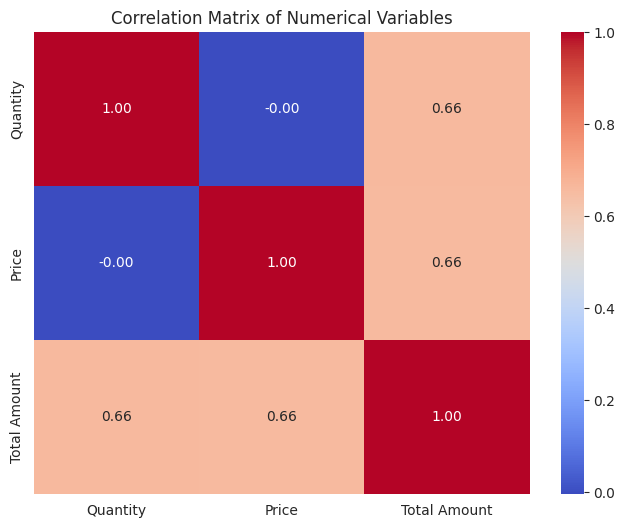

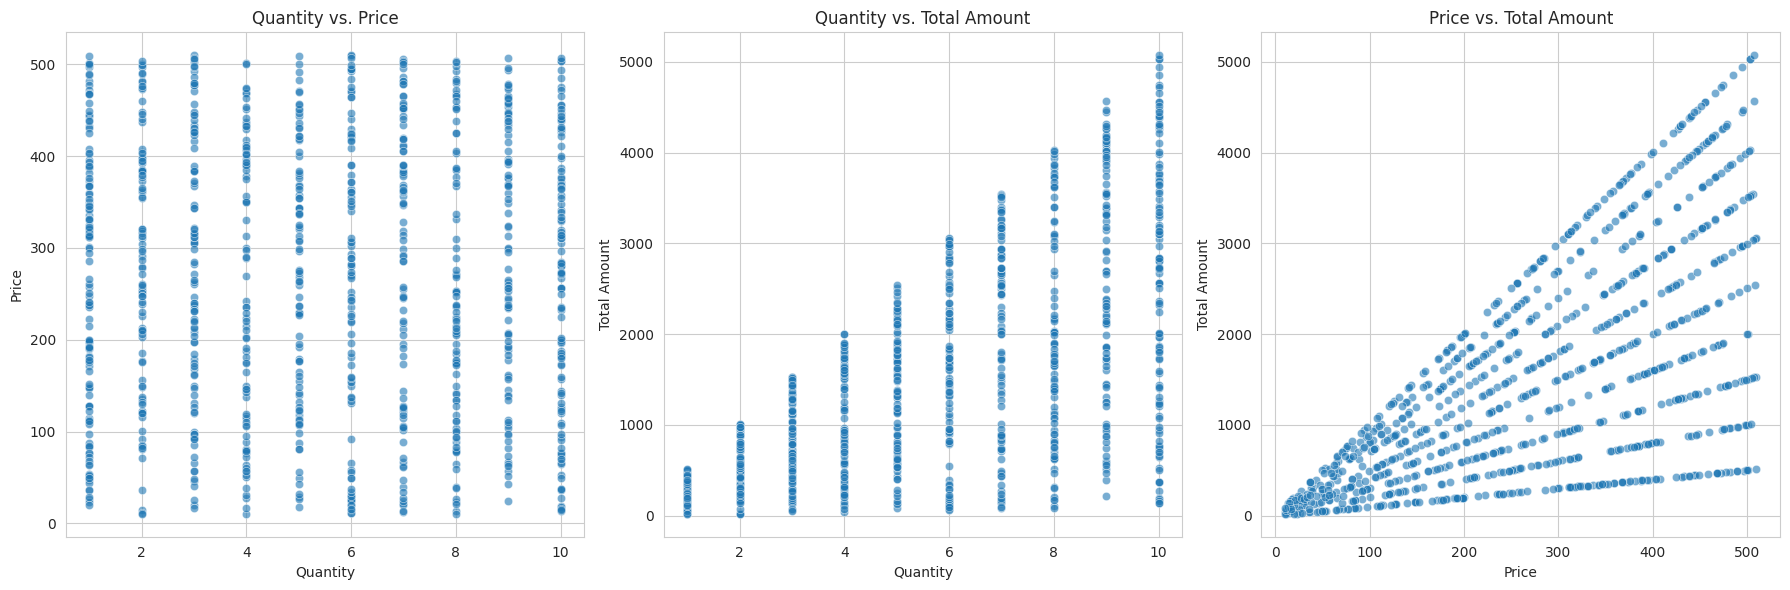

In [6]:
# Correlation matrix for numerical variables
correlation_matrix = df_cleaned[['Quantity', 'Price', 'Total Amount']].corr()
print("Correlation Matrix for Numerical Variables:\n")
display(correlation_matrix)

# Visualize correlations using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

# Scatter plots for numerical variables
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.scatterplot(x='Quantity', y='Price', data=df_cleaned, alpha=0.6)
plt.title('Quantity vs. Price')

plt.subplot(1, 3, 2)
sns.scatterplot(x='Quantity', y='Total Amount', data=df_cleaned, alpha=0.6)
plt.title('Quantity vs. Total Amount')

plt.subplot(1, 3, 3)
sns.scatterplot(x='Price', y='Total Amount', data=df_cleaned, alpha=0.6)
plt.title('Price vs. Total Amount')

plt.tight_layout()
plt.show()

## Multivariable Analysis

### Temporal Analysis of Total Amount

I will extract the year and month from the 'Date' column to analyze trends in 'Total Amount' over time. This will help us understand seasonality or long-term growth/decline.

Total Amount by Year and Month:



,Order Year,Order Month,Total Amount
0,2022,December,2475.36
5,2023,January,59838.73
4,2023,February,68742.85
8,2023,March,68378.01
1,2023,April,65418.81


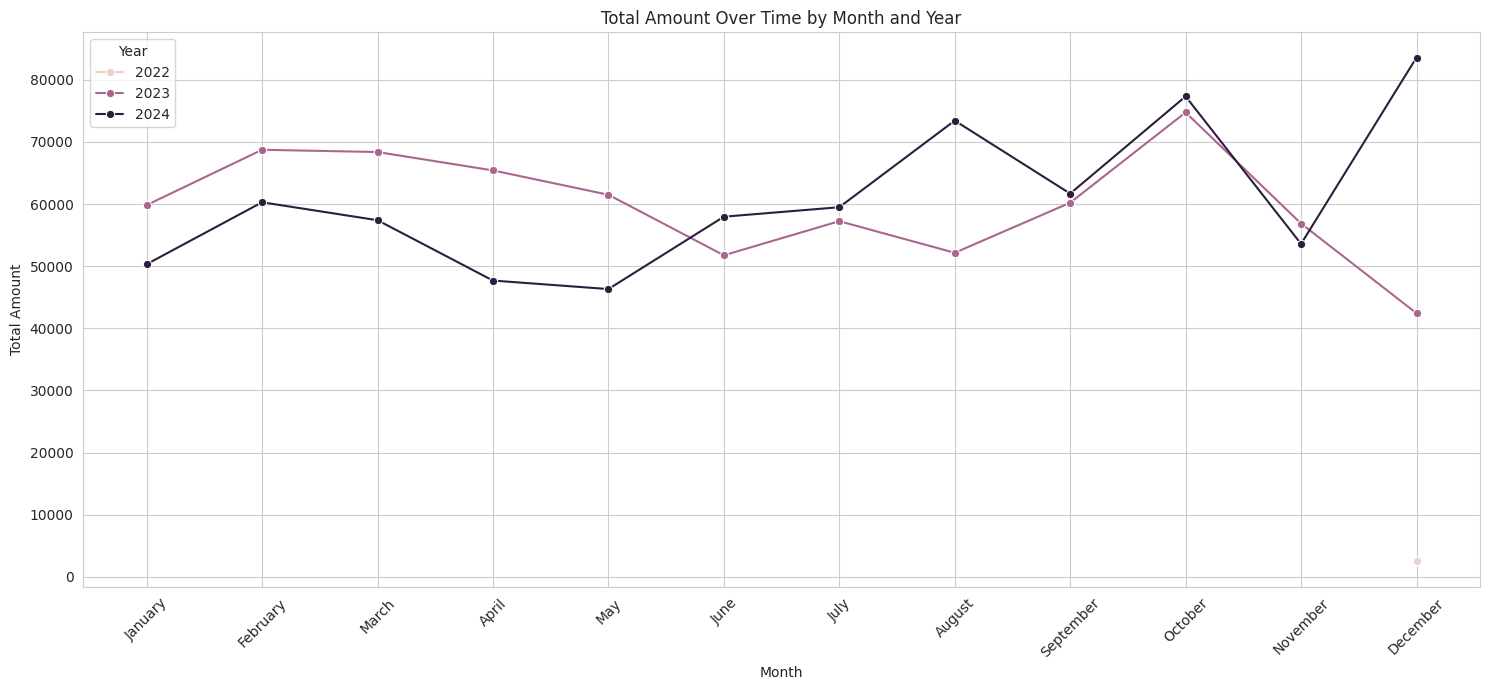

In [7]:
# Extract Year and Month from the Date column
df_cleaned['Order Year'] = df_cleaned['Date'].dt.year
df_cleaned['Order Month'] = df_cleaned['Date'].dt.month_name()

# Group by Year and Month to see trends in Total Amount
trend_data = df_cleaned.groupby(['Order Year', 'Order Month'])['Total Amount'].sum().reset_index()

# Order months correctly for plotting
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July',
               'August', 'September', 'October', 'November', 'December']
trend_data['Order Month'] = pd.Categorical(trend_data['Order Month'], categories=month_order, ordered=True)

# Sort for proper time series plotting
trend_data = trend_data.sort_values(by=['Order Year', 'Order Month'])

print("Total Amount by Year and Month:\n")
display(trend_data.head())

# Plotting total amount over time
plt.figure(figsize=(15, 7))
sns.lineplot(x='Order Month', y='Total Amount', hue='Order Year', data=trend_data, marker='o')
plt.title('Total Amount Over Time by Month and Year')
plt.xlabel('Month')
plt.ylabel('Total Amount')
plt.xticks(rotation=45)
plt.legend(title='Year')
plt.tight_layout()
plt.show()

### Average Total Amount by Category and Country

I will analyze the average 'Total Amount' by product category within each country to understand regional preferences and market performance. This will be visualized using a grouped bar chart.

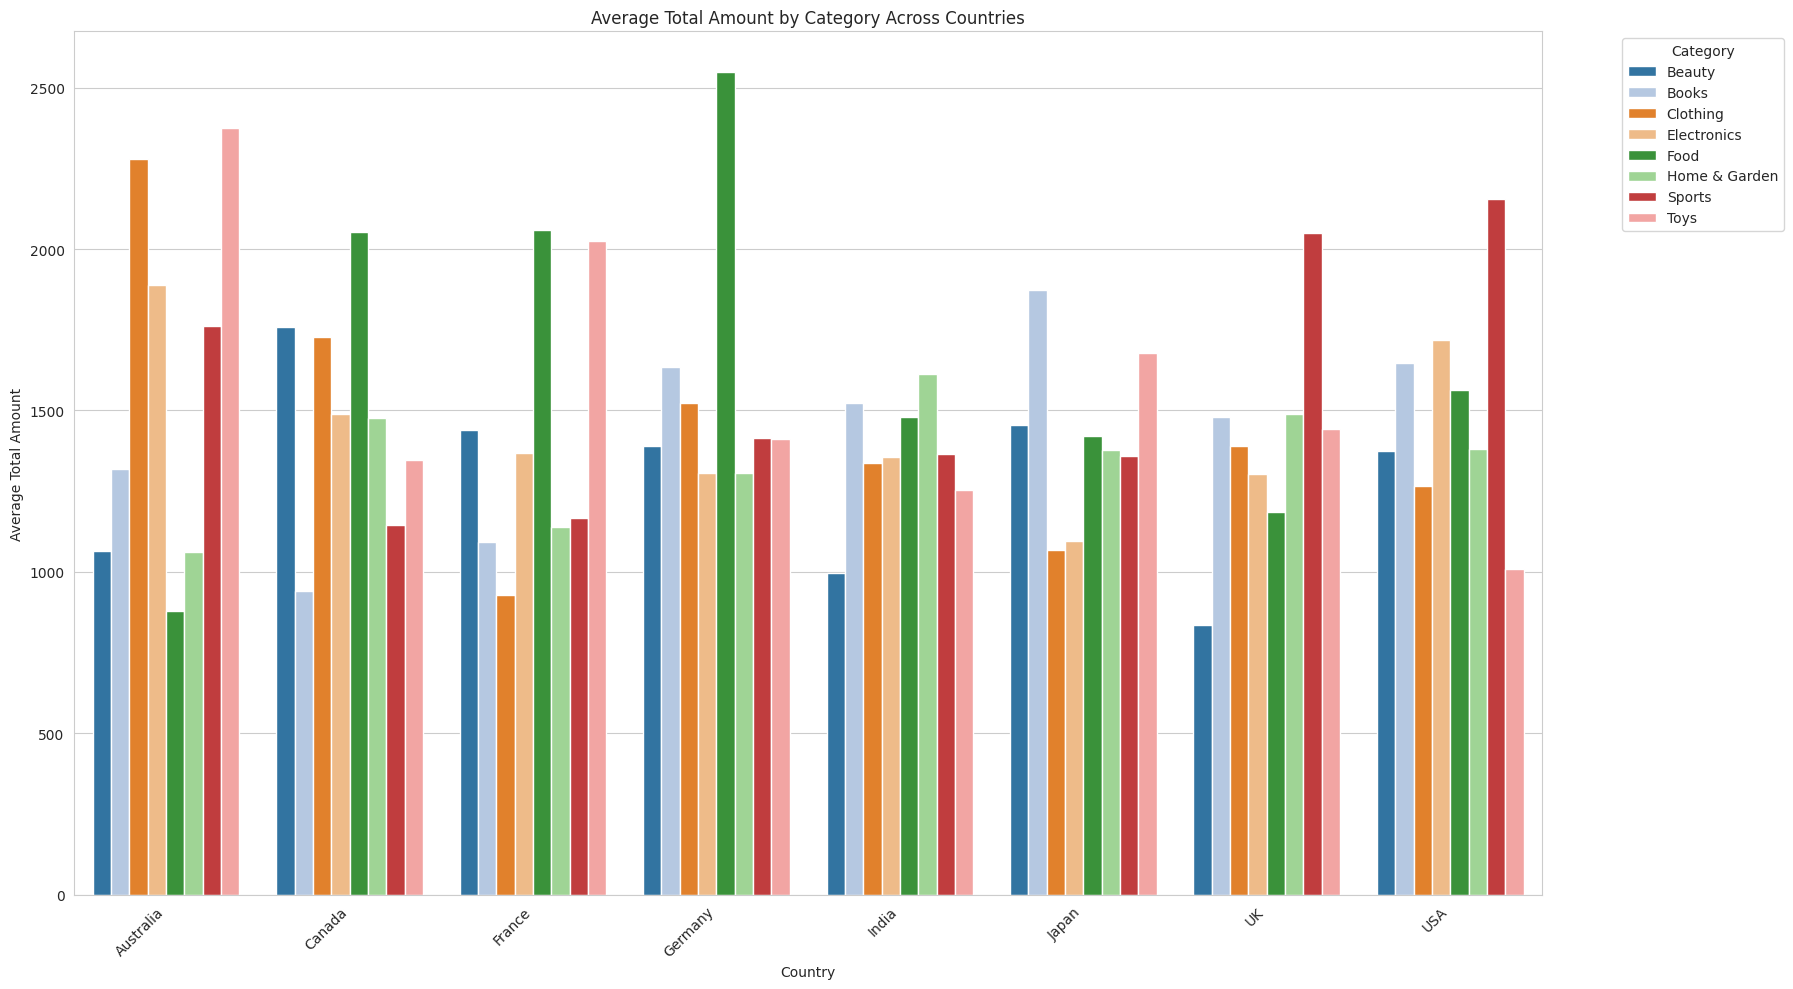

In [8]:
# Group by Country and Category to find average Total Amount
cross_analysis_country_category = df_cleaned.groupby(['Country', 'Category'])['Total Amount'].mean().reset_index()

# Plotting average total amount by category in each country
plt.figure(figsize=(18, 10))
sns.barplot(x='Country', y='Total Amount', hue='Category', data=cross_analysis_country_category, palette='tab20')
plt.title('Average Total Amount by Category Across Countries')
plt.xlabel('Country')
plt.ylabel('Average Total Amount')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Regression Modeling

Now, I will build a regression model to predict a variable. Based on the data, 'Total Amount' seems to be a good candidate for prediction, as it's a key business metric. I'll use `Quantity` and `Price` as numerical features, and `Category`, `Country`, `Payment Method`, and `Status` as categorical features after one-hot encoding them. I will split the data into training and testing sets, train a `RandomForestRegressor`, and evaluate its performance.

Mean Squared Error (MSE): 1459.03
R-squared (R2): 1.00


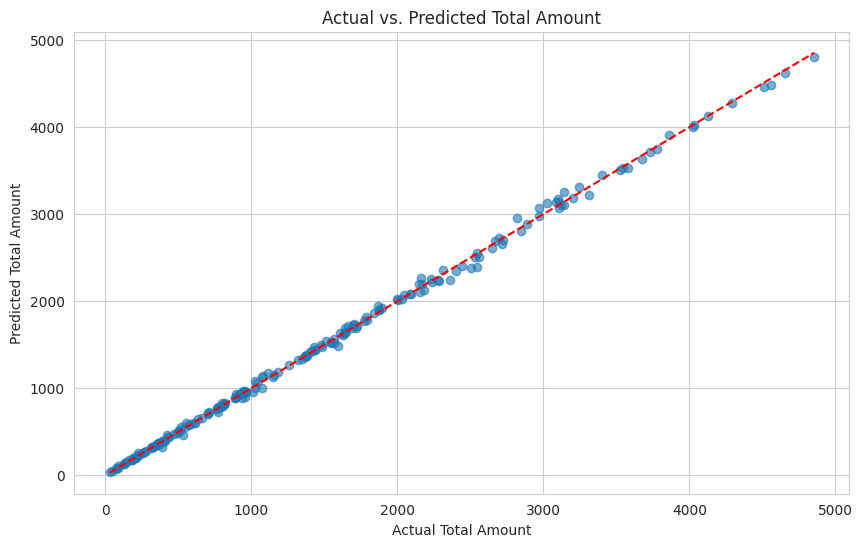

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define features (X) and target (y)
X = df_cleaned[['Quantity', 'Price', 'Category', 'Country', 'Payment Method', 'Status']]
y = df_cleaned['Total Amount']

# Identify categorical and numerical features
categorical_features = ['Category', 'Country', 'Payment Method', 'Status']
numerical_features = ['Quantity', 'Price']

# Create a column transformer for one-hot encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ], remainder='passthrough'
)

# Create a pipeline with preprocessing and the regressor
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model_pipeline.fit(X_train, y_train)

# Make predictions
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Optionally, visualize predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Total Amount')
plt.ylabel('Predicted Total Amount')
plt.title('Actual vs. Predicted Total Amount')
plt.grid(True)
plt.show()

### Predict 'Total Amount' for a New Sample

Now, I will demonstrate how to use the trained `model_pipeline` to predict the 'Total Amount' for a new, hypothetical sample row. I will create a pandas DataFrame representing this new sample with appropriate values for the features used during training.

In [10]:
import pandas as pd

# Create a new sample row for prediction
new_sample = pd.DataFrame({
    'Quantity': [5],
    'Price': [250.00],
    'Category': ['Electronics'],
    'Country': ['USA'],
    'Payment Method': ['Credit Card'],
    'Status': ['Completed']
})

# Make prediction using the trained model pipeline
predicted_amount = model_pipeline.predict(new_sample)

print(f"Predicted Total Amount for the new sample: ${predicted_amount[0]:.2f}")

Predicted Total Amount for the new sample: $1255.33


## E-commerce Dashboard: Key Insights

This section presents a dashboard summarizing the key aspects of the e-commerce data through various visualizations. It combines insights from the univariable, bivariable, and multivariable analyses to provide a comprehensive overview.

### 1. Total Amount Over Time

This plot shows the trend of total sales amount aggregated by month and year, revealing any seasonality or long-term patterns.

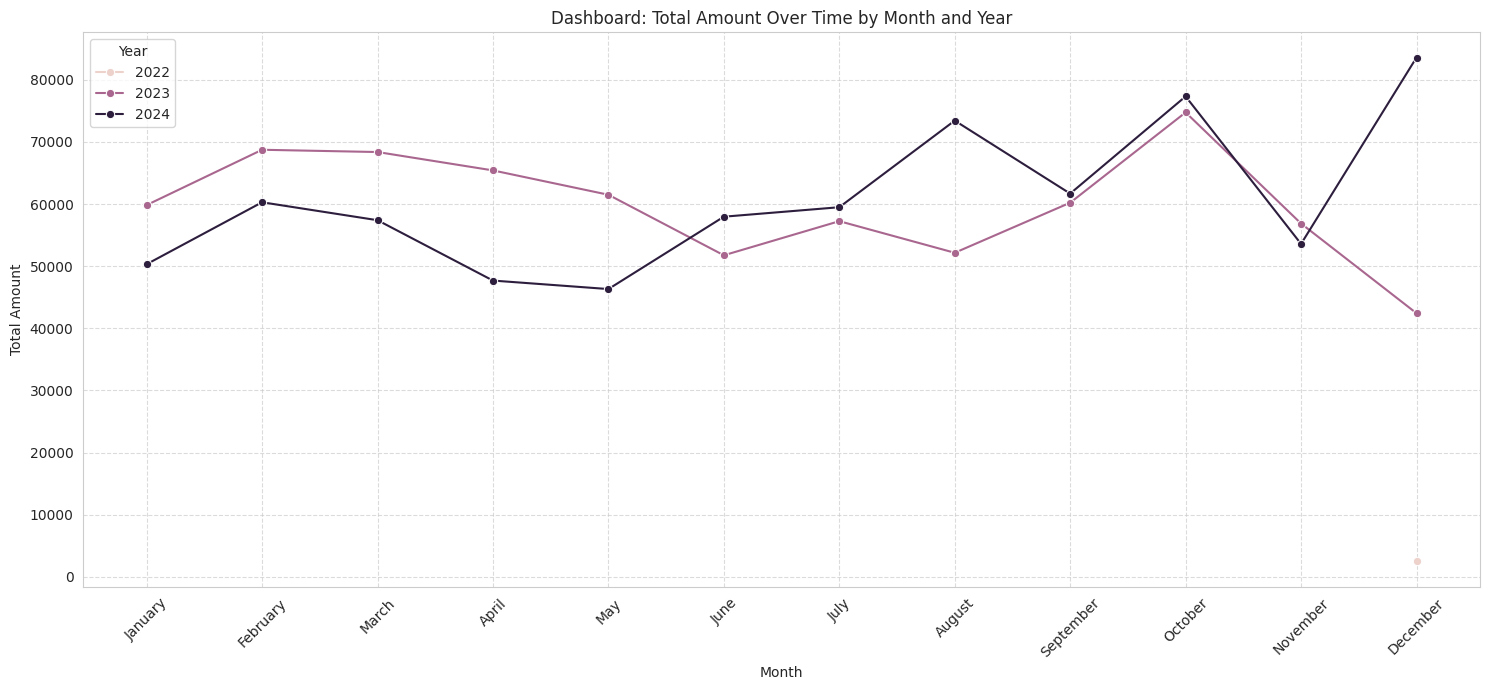

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'Date' column is datetime and extract year/month for plotting
if 'Date' in df_cleaned.columns and not pd.api.types.is_datetime64_any_dtype(df_cleaned['Date']):
    df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'])

df_cleaned['Order Year'] = df_cleaned['Date'].dt.year
df_cleaned['Order Month'] = df_cleaned['Date'].dt.month_name()

# Group by Year and Month to see trends in Total Amount
trend_data = df_cleaned.groupby(['Order Year', 'Order Month'])['Total Amount'].sum().reset_index()

# Order months correctly for plotting
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July',
               'August', 'September', 'October', 'November', 'December']
trend_data['Order Month'] = pd.Categorical(trend_data['Order Month'], categories=month_order, ordered=True)

# Sort for proper time series plotting
trend_data = trend_data.sort_values(by=['Order Year', 'Order Month'])

plt.figure(figsize=(15, 7))
sns.lineplot(x='Order Month', y='Total Amount', hue='Order Year', data=trend_data, marker='o')
plt.title('Dashboard: Total Amount Over Time by Month and Year')
plt.xlabel('Month')
plt.ylabel('Total Amount')
plt.xticks(rotation=45)
plt.legend(title='Year')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 2. Sales Distribution by Key Categorical Variables

These box plots illustrate the distribution of 'Total Amount' across different countries, product categories, payment methods, and order statuses, highlighting variability and central tendencies within each group.

/tmp/ipykernel_16098/4189251535.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Total Amount', y=col, data=df_cleaned, palette='viridis')
/tmp/ipykernel_16098/4189251535.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Total Amount', y=col, data=df_cleaned, palette='viridis')
/tmp/ipykernel_16098/4189251535.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Total Amount', y=col, data=df_cleaned, palette='viridis')
/tmp/ipykernel_16098/4189251535.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecat

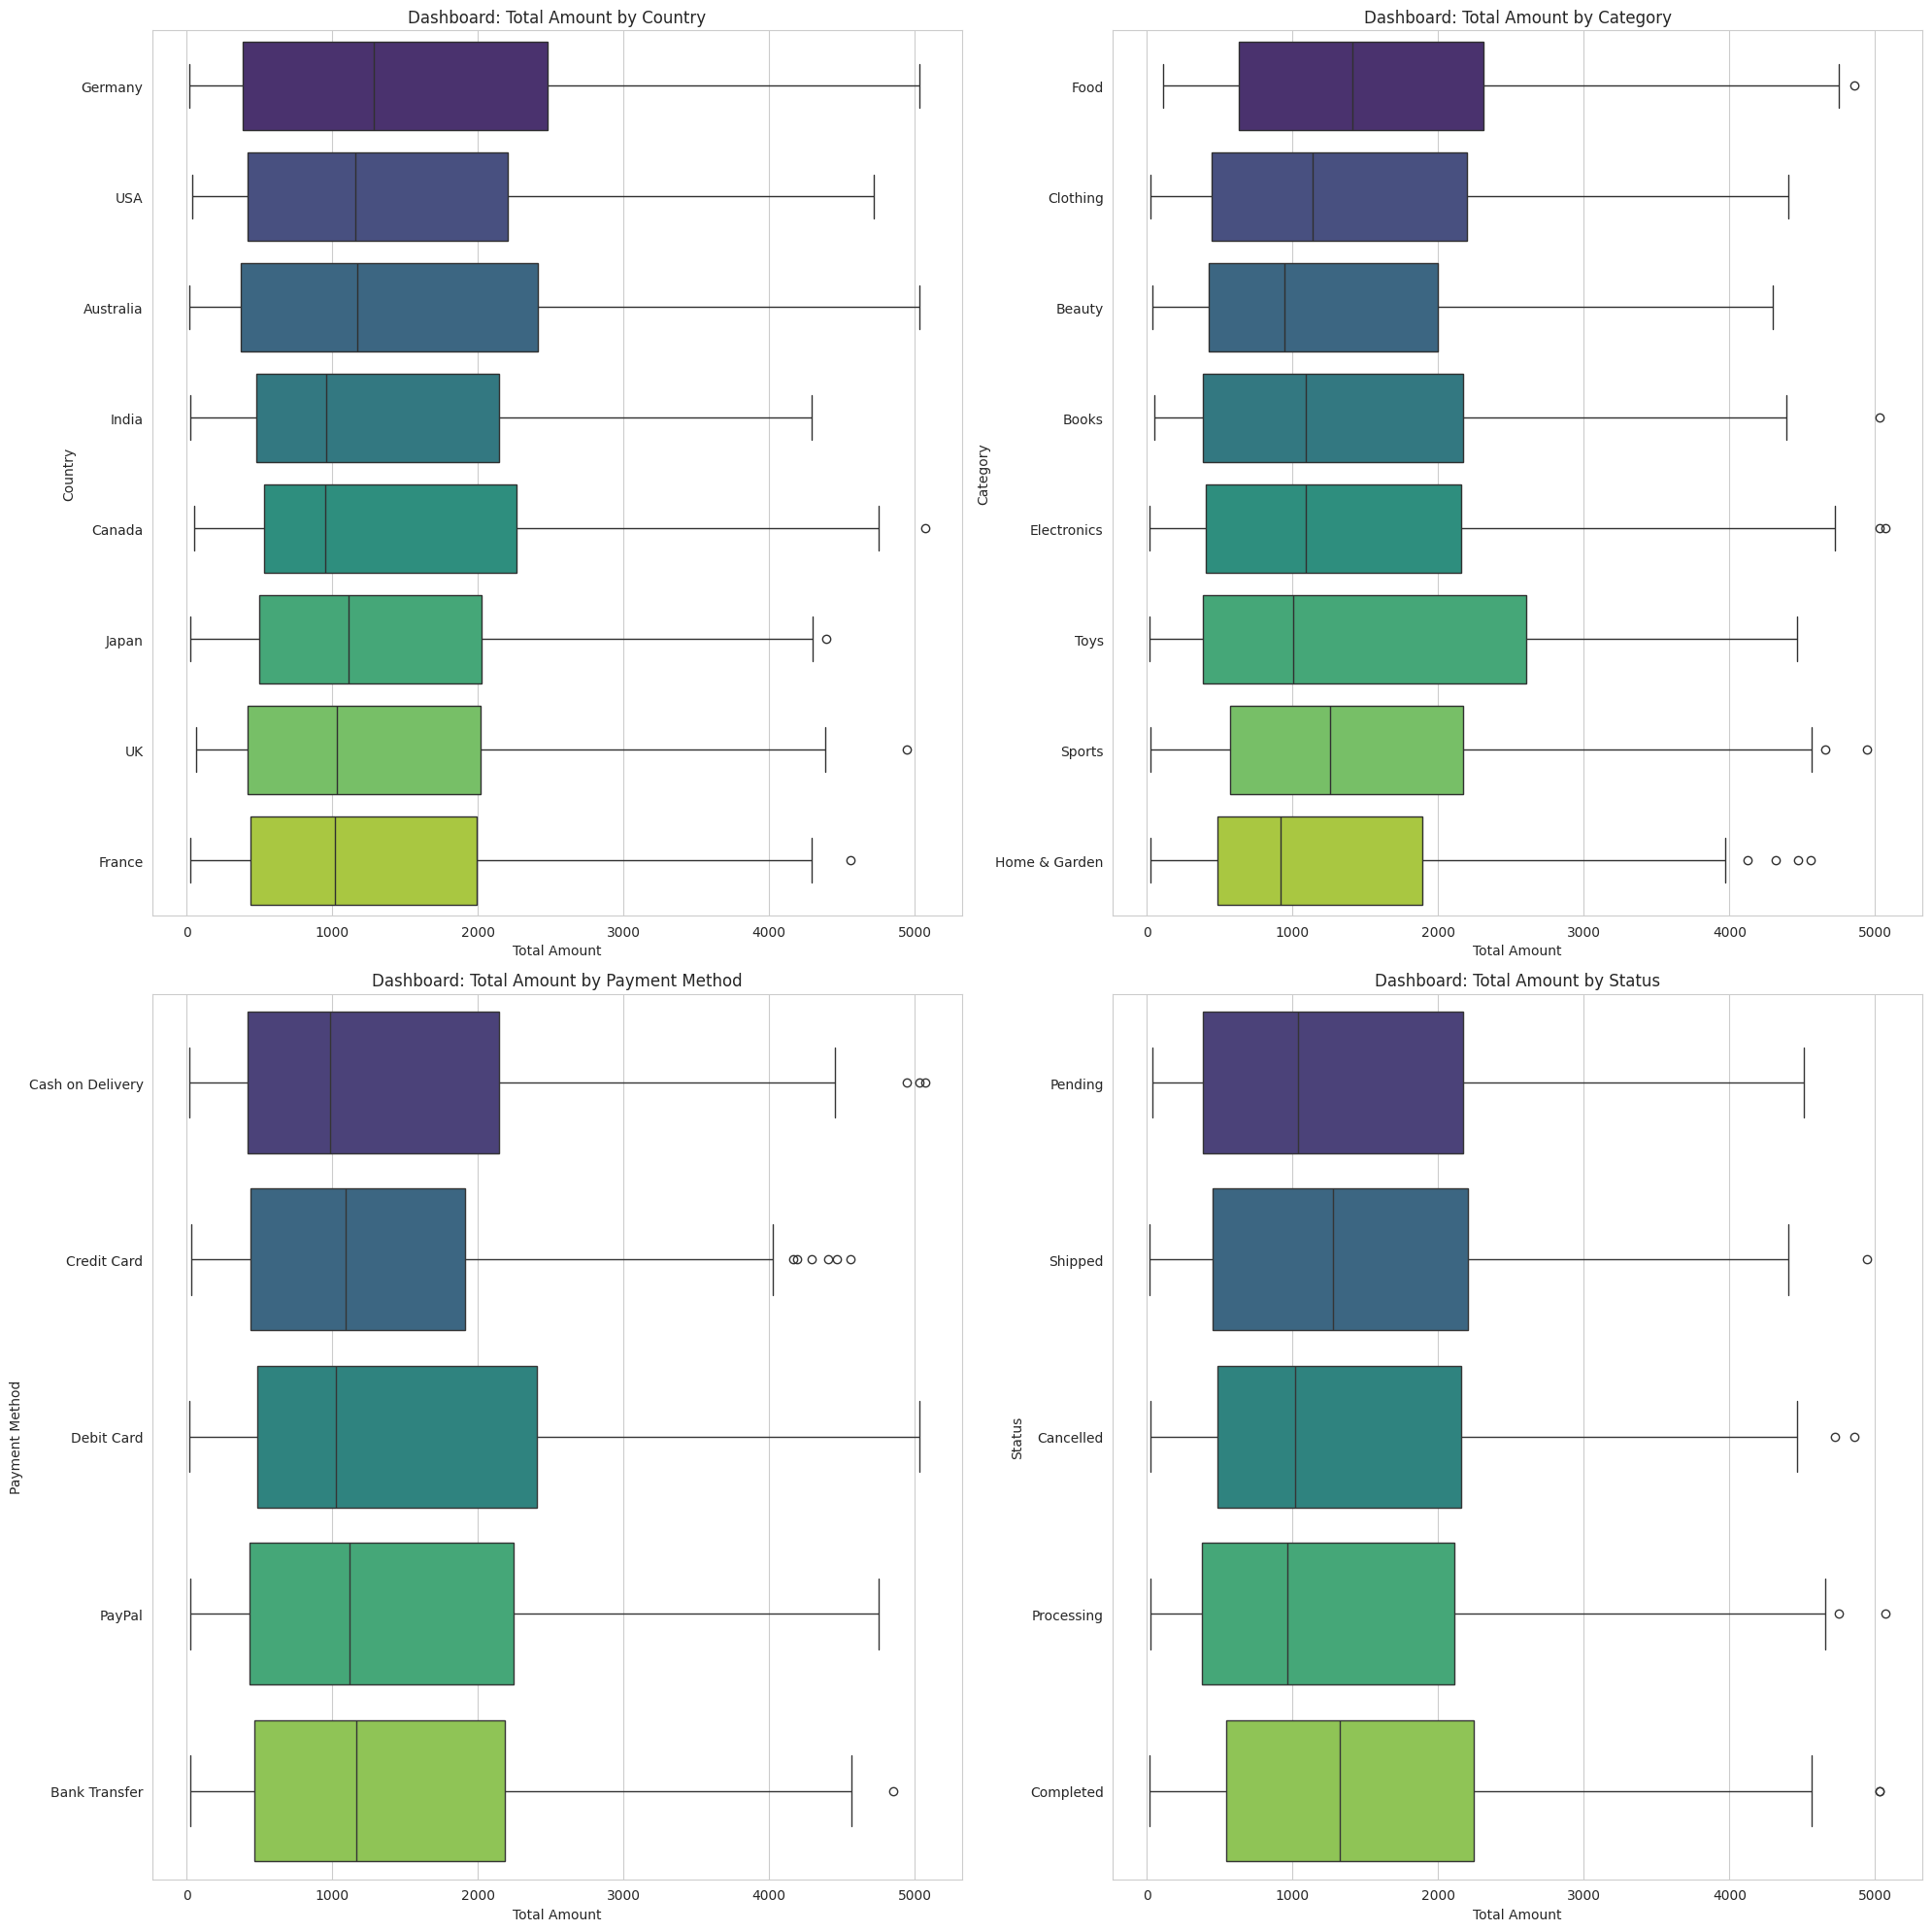

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

categorical_cols_dashboard = ['Country', 'Category', 'Payment Method', 'Status']

plt.figure(figsize=(20, 20))
for i, col in enumerate(categorical_cols_dashboard, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='Total Amount', y=col, data=df_cleaned, palette='viridis')
    plt.title(f'Dashboard: Total Amount by {col}')
    plt.xlabel('Total Amount')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

### 3. Top 5 Categories and Countries by Total Sales

These bar plots show the top 5 performing product categories and countries based on the aggregated total sales, indicating key revenue drivers.

/tmp/ipykernel_16098/4158472756.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total Amount', y='Category', data=top_categories, palette='Blues_d')
/tmp/ipykernel_16098/4158472756.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total Amount', y='Country', data=top_countries, palette='Greens_d')


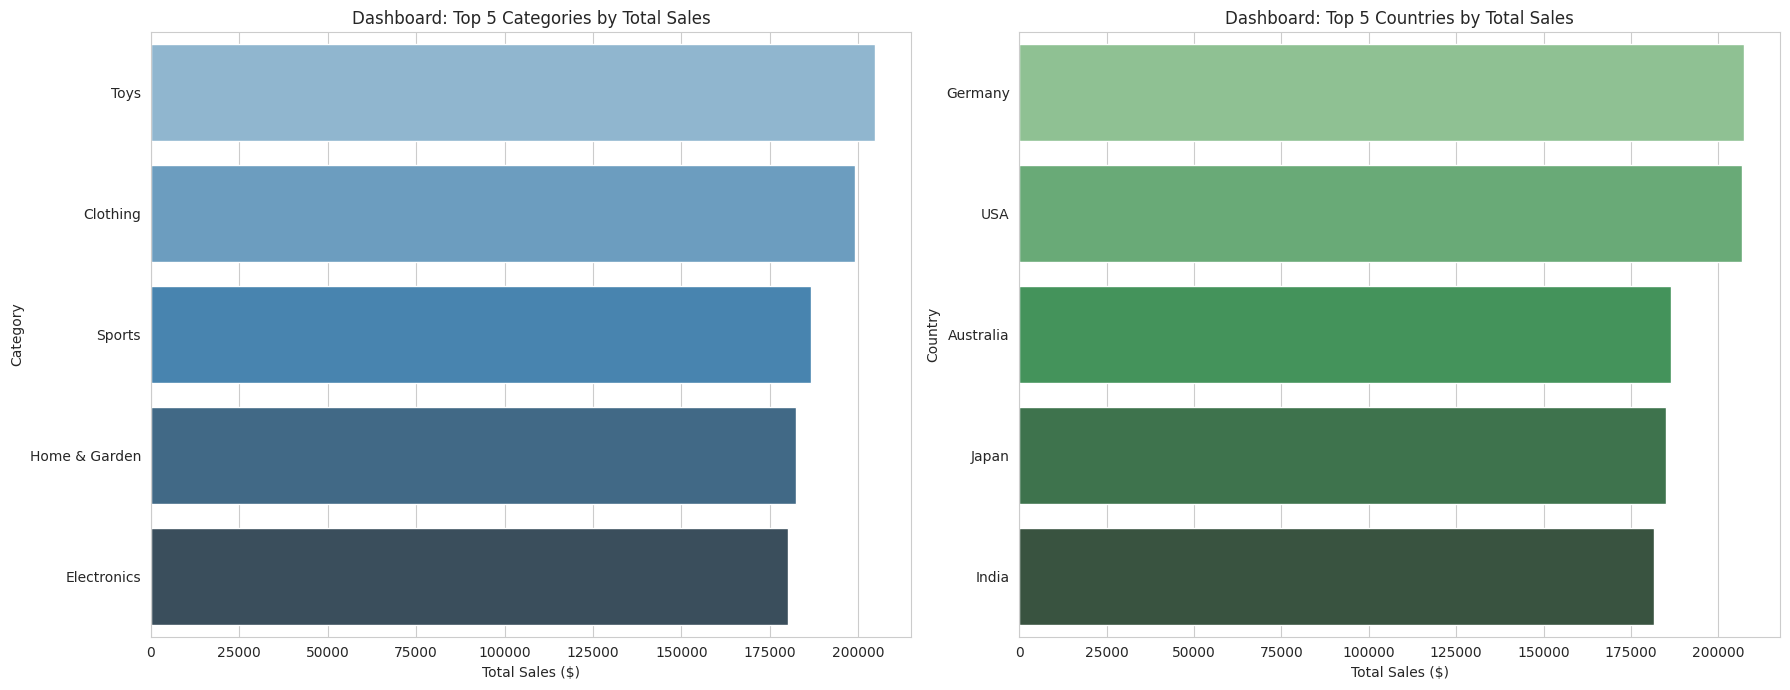

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 5 Categories by Total Amount
top_categories = df_cleaned.groupby('Category')['Total Amount'].sum().nlargest(5).reset_index()

# Top 5 Countries by Total Amount
top_countries = df_cleaned.groupby('Country')['Total Amount'].sum().nlargest(5).reset_index()

plt.figure(figsize=(18, 7))

plt.subplot(1, 2, 1)
sns.barplot(x='Total Amount', y='Category', data=top_categories, palette='Blues_d')
plt.title('Dashboard: Top 5 Categories by Total Sales')
plt.xlabel('Total Sales ($)')
plt.ylabel('Category')

plt.subplot(1, 2, 2)
sns.barplot(x='Total Amount', y='Country', data=top_countries, palette='Greens_d')
plt.title('Dashboard: Top 5 Countries by Total Sales')
plt.xlabel('Total Sales ($)')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

### 4. Correlation of Numerical Variables

This heatmap visualizes the correlation matrix between numerical variables (`Quantity`, `Price`, `Total Amount`), highlighting their linear relationships.

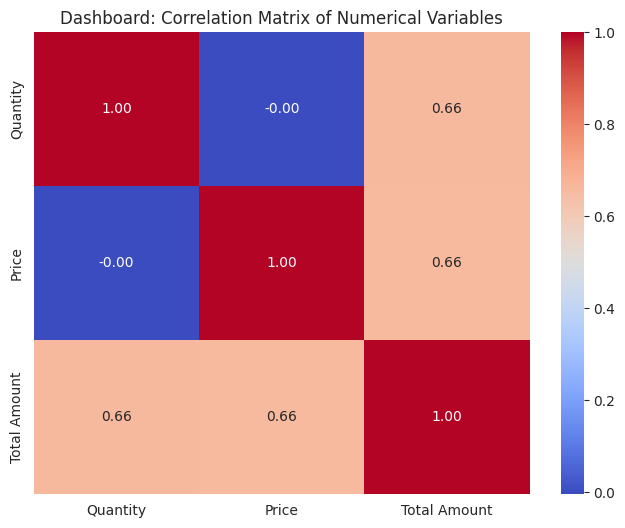

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation matrix for numerical variables
correlation_matrix = df_cleaned[['Quantity', 'Price', 'Total Amount']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Dashboard: Correlation Matrix of Numerical Variables')
plt.show()

## Total Sales Calculation

I will calculate the total sales by summing the 'Total Amount' column from the cleaned DataFrame.

In [15]:
total_sales = df_cleaned['Total Amount'].sum()
print(f"Our total sales are: ${total_sales:,.2f}")

Our total sales are: $1,450,872.57
